<a href="https://colab.research.google.com/github/francescopatane96/eNERVE/blob/main/4_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#4 **Feature selection**

in this notebook we will concatenate all descriptors and csv contains pathogenic eukaryotic proteins. the scope of this project consists of selecting features highly correlated with the target variable 'Subcellular location'. 

1. concatenate descriptors and target variable dataset
2. Analyze matrix correlation
3. dimensionality reduction
4. create a new dataset

In [ ]:
import pandas as pd

In [ ]:
#read descriptors and proteins table
aac = pd.read_csv('AAC.csv', header=0, sep='\t')
aac.rename(columns={'#':'Entry'}, inplace=True)
#aac.set_index('Entry')
dpc = pd.read_csv('DPC.csv', header=0, sep='\t')
dpc.rename(columns={'#':'Entry'}, inplace=True)
dde = pd.read_csv('DDE.csv', header=0, sep='\t')
dde.rename(columns={'#':'Entry'}, inplace=True)
ctdc = pd.read_csv('CTDC.csv', header=0, sep='\t')
ctdc.rename(columns={'#':'Entry'}, inplace=True)
ctdd = pd.read_csv('CTDD.csv', header=0, sep='\t')
ctdd.rename(columns={'#':'Entry'}, inplace=True)
ctdt = pd.read_csv('CTDT.csv', header=0, sep='\t')
ctdt.rename(columns={'#':'Entry'}, inplace=True)
gaac = pd.read_csv('GAAC.csv', header=0, sep='\t')
gaac.rename(columns={'#':'Entry'}, inplace=True)
gdpc = pd.read_csv('GDPC.csv', header=0, sep='\t')
gdpc.rename(columns={'#':'Entry'}, inplace=True)
gtpc = pd.read_csv('GTPC.csv', header=0, sep='\t')
gtpc.rename(columns={'#':'Entry'}, inplace=True)
final_prot = pd.read_csv('train.csv', index_col='Entry')

In [ ]:
display(final_prot)

In [ ]:
display(aac)

In [ ]:
#concatenate files
full_matrix = pd.concat([aac, dpc, dde, ctdc, ctdd, ctdt, gaac, gdpc, gtpc, final_prot], axis=1, ignore_index=False) 
#full_matrix =  full_matrix.drop(['Entry'], axis=1)
#full_matrix = full_matrix.T.drop_duplicates().T   #drop entry columns duplicates


In [ ]:
frames = [aac, dpc, dde, ctdc, ctdd, ctdt, gaac, gdpc, gtpc, final_prot]

In [ ]:
from functools import reduce

In [ ]:
merged = reduce(lambda left,right: pd.merge(left,right,on=['Entry'], how='outer'), frames)

In [ ]:
display(merged)

,Entry,A,C,D,E,F,G,H,I,K,...,uncharger.uncharger.postivecharger,uncharger.uncharger.negativecharger,uncharger.uncharger.uncharger,Subcellular location,Unnamed: 1,Sequence,in,in_mem,mem,out
0,GTR2_YEAST,0.055718,0.011730,0.079179,0.067449,0.041056,0.035191,0.014663,0.090909,0.049853,...,0.008850,0.011799,0.020649,in_mem,143,MSLEATDSKAMVLLMGVRRCGKSSICKVVFHNMQPLDTLYLESTSN...,0,1,0,0
1,SPC1_YEAST,0.063830,0.031915,0.042553,0.031915,0.042553,0.031915,0.000000,0.095745,0.074468,...,0.021739,0.000000,0.021739,in_mem,149,MSEILQDVQRKLVFPIDFPSQRKTEKFQQLSLMIGALVACILGFAQ...,0,1,0,0
2,YD090_YEAST,0.077419,0.025806,0.058065,0.035484,0.064516,0.064516,0.012903,0.106452,0.045161,...,0.003247,0.003247,0.006494,mem,41,MISEKAATALATIATVCWCVQLIPQIIYNWKKKDCTGLPPLMMFLW...,0,0,1,0
3,DFM1_YEAST,0.046921,0.014663,0.026393,0.017595,0.058651,0.093842,0.011730,0.073314,0.017595,...,0.008850,0.005900,0.041298,in_mem,130,MAGPRNVRTLHGNGGRNNDVMGPKEFWLNIPPITRTLFTLAIVMTI...,0,1,0,0
4,CP51_YEAST,0.056604,0.007547,0.047170,0.058491,0.050943,0.064151,0.033962,0.062264,0.069811,...,0.003788,0.009470,0.018939,in_mem,89,MSATKSIVGEALEYVNIGLSHFLALPLAQRISLIIIIPFIYNIVWQ...,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,CID13_SCHPO,0.044983,0.027682,0.069204,0.041522,0.064014,0.036332,0.024221,0.050173,0.044983,...,0.008681,0.013889,0.055556,in,71,MDNANCVGGCKFETRSFQYRRRIPYSLGADPLPPVHPLSLKNLVDI...,1,0,0,0
639,ARP10_SCHPO,0.060526,0.023684,0.063158,0.060526,0.034211,0.042105,0.007895,0.084211,0.060526,...,0.018519,0.010582,0.026455,in,106,MRKNCDISTVVVQIDEFGIYIGNASDKEPTWKVDLVPYKQSWVPIS...,1,0,0,0
640,ATP25_YEAST,0.037582,0.011438,0.045752,0.066993,0.044118,0.047386,0.027778,0.062092,0.083333,...,0.014754,0.008197,0.031148,in_mem,69,MNKFCLLPFHGKRIGVANIPFTILFKKGPYFLHSHITAVYYSTKGK...,0,1,0,0
641,SSP1_YEAST,0.036778,0.007005,0.056042,0.099825,0.045534,0.028021,0.015762,0.054291,0.096322,...,0.019332,0.015817,0.056239,mem,33,MRSSGTYENDPSGEITSTSPKQSKQKKPTKFRERMRRWLQNGKNNN...,0,0,1,0


In [ ]:
col_to_drop = ['Entry', 'Subcellular location', 'Unnamed: 1', 'Sequence']

In [ ]:
merged = merged.drop(col_to_drop, axis=1)

In [ ]:
display(merged)

,A,C,D,E,F,G,H,I,K,L,...,uncharger.negativecharger.uncharger,uncharger.uncharger.alphaticr,uncharger.uncharger.aromatic,uncharger.uncharger.postivecharger,uncharger.uncharger.negativecharger,uncharger.uncharger.uncharger,in,in_mem,mem,out
0,0.055718,0.011730,0.079179,0.067449,0.041056,0.035191,0.014663,0.090909,0.049853,0.108504,...,0.005900,0.041298,0.002950,0.008850,0.011799,0.020649,0,1,0,0
1,0.063830,0.031915,0.042553,0.031915,0.042553,0.031915,0.000000,0.095745,0.074468,0.127660,...,0.000000,0.032609,0.000000,0.021739,0.000000,0.021739,0,1,0,0
2,0.077419,0.025806,0.058065,0.035484,0.064516,0.064516,0.012903,0.106452,0.045161,0.087097,...,0.003247,0.022727,0.016234,0.003247,0.003247,0.006494,0,0,1,0
3,0.046921,0.014663,0.026393,0.017595,0.058651,0.093842,0.011730,0.073314,0.017595,0.085044,...,0.008850,0.041298,0.014749,0.008850,0.005900,0.041298,0,1,0,0
4,0.056604,0.007547,0.047170,0.058491,0.050943,0.064151,0.033962,0.062264,0.069811,0.098113,...,0.003788,0.024621,0.007576,0.003788,0.009470,0.018939,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,0.044983,0.027682,0.069204,0.041522,0.064014,0.036332,0.024221,0.050173,0.044983,0.086505,...,0.019097,0.041667,0.013889,0.008681,0.013889,0.055556,1,0,0,0
639,0.060526,0.023684,0.063158,0.060526,0.034211,0.042105,0.007895,0.084211,0.060526,0.105263,...,0.007937,0.026455,0.013228,0.018519,0.010582,0.026455,1,0,0,0
640,0.037582,0.011438,0.045752,0.066993,0.044118,0.047386,0.027778,0.062092,0.083333,0.124183,...,0.008197,0.037705,0.008197,0.014754,0.008197,0.031148,0,1,0,0
641,0.036778,0.007005,0.056042,0.099825,0.045534,0.028021,0.015762,0.054291,0.096322,0.078809,...,0.019332,0.033392,0.010545,0.019332,0.015817,0.056239,0,0,1,0


In [ ]:
merged.dtypes

In [ ]:
merged.to_csv('full_matrix_train.tsv', sep='\t', index=False, header=0)  #export file for iLearn

In [ ]:
merged.to_csv('full_matrix_train.csv')

Feature analysis, selection, dimensionality reduction

In [ ]:
#clone iLearn package from Github
!git clone https://github.com/Superzchen/iLearn

In [ ]:
#clustering kmeans

In [ ]:
!python iLearn/iLearn-clustering.py --file full_matrix_train.tsv --method kmeans --sof sample --nclusters 3

Cluster method: kmeans


feature normalization

In [ ]:
!python iLearn/iLearn-feature-normalization.py --file full_matrix.tsv --method ZScore --format tsv

feature selection

In [ ]:
!python iLearn/iLearn-feature-selectior.py --file full_matrix_train.tsv --method pearsonr --format tsv

Traceback (most recent call last):
  File "iLearn/iLearn-feature-selectior.py", line 22, in <module>
    encodings, labels = read_code.read_code(args.file, format=args.format)
  File "/content/iLearn/pubscripts/read_code.py", line 128, in read_code
    encodings, labels = read_tsv(file)
  File "/content/iLearn/pubscripts/read_code.py", line 64, in read_tsv
    labels.append(int(array[0]))
ValueError: invalid literal for int() with base 10: '0.0557184750733137'


Dimensionality reduction

In [ ]:
!python iLearn/iLearn-dimension-reduction.py --file full_matrix_train.tsv --method pca --format tsv

Traceback (most recent call last):
  File "iLearn/iLearn-dimension-reduction.py", line 21, in <module>
    encodings, labels = read_code.read_code(args.file, format=args.format)
  File "/content/iLearn/pubscripts/read_code.py", line 128, in read_code
    encodings, labels = read_tsv(file)
  File "/content/iLearn/pubscripts/read_code.py", line 64, in read_tsv
    labels.append(int(array[0]))
ValueError: invalid literal for int() with base 10: '0.0557184750733137'


EDA, exploratory data analysis

we want to analyze the correlation between features and target variables (dummy variables) by creating a correlation matrix and the relative heatmap.

In [ ]:
!pip install pandas-profiling==3.3.0

In [ ]:
from pandas_profiling import ProfileReport

In [ ]:
full_matrix = full_matrix.drop('Entry', axis=1)

In [ ]:
full_matrix = full_matrix.drop('Sequence_x', axis=1)

In [ ]:
full_matrix = full_matrix.drop('Organism', axis=1)

In [ ]:
display(full_matrix)
full_matrix.to_csv('full_matrix.tsv', sep='\t')  #export file for iLearn

In [ ]:
full_matrix = full_matrix.drop('Subcellular location ', axis=1)

In [ ]:
full_matrix.to_csv('full_matrix.csv', sep=',')  #export file for iLearn

In [ ]:
full=full_matrix.copy()
display(full)

In [ ]:
#prova 1
full_dummies = pd.get_dummies(full_matrix['Subcellular location '])
#del full_dummies[full_dummies.columns[-1]]
full_matrix = pd.concat([full_matrix, full_dummies], axis=1)
del full_matrix['Subcellular location ']
display(full_matrix)

A         C         D         E         F  \
Subcellular location                                                          
in                    0    0.044571  0.014857  0.057143  0.049143      0.04   
                      1    0.065134  0.011494  0.076628  0.042146  0.068966   
                      2    0.089021  0.011869  0.048961  0.051929  0.040059   
                      3    0.041667  0.033854  0.052083  0.059896  0.059896   
                      4    0.110307       0.0  0.041591  0.090416    0.0217   
...                             ...       ...       ...       ...       ...   
out                   331  0.084469  0.002725  0.051771  0.079019  0.040872   
                      332  0.076795  0.013356  0.058431  0.071786  0.055092   
                      333  0.152913   0.01699  0.048544  0.036408   0.01699   
                      334  0.077273  0.012121  0.054545  0.036364  0.031818   
                      335   0.09589  0.018265  0.013699  0.063927  0.018265   

                                  G         H         I         K         L  \
Subcellular location                                                          
in                    0    0.052571  0.009143  0.081143  0.077714  0.107429   
                      1    0.042146  0.011494  0.076628  0.095785  0.065134   
                      2    0.097923  0.013353  0.069733  0.057864   0.08457   
                      3    0.052083  0.015625  0.075521  0.059896  0.085938   
                      4    0.052441  0.019892  0.030741   0.03255  0.084991   
...                             ...       ...       ...       ...       ...   
out                   331  0.043597  0.016349   0.06267   0.06812  0.100817   
                      332   0.06177  0.028381  0.045075  0.063439  0.113523   
                      333  0.070388  0.019417  0.036408  0.050971  0.026699   
                      334  0.089394  0.018182  0.059091  0.019697  0.093939   
                      335  0.059361  0.027397   0.03653  0.013699  0.054795   

                           ... uncharger.negativecharger.negativecharger  \
Subcellular location       ...                                             
in                    0    ...                                  0.004582   
                      1    ...                                  0.003861   
                      2    ...                                  0.002976   
                      3    ...                                  0.005236   
                      4    ...                                   0.00363   
...                        ...                                       ...   
out                   331  ...                                  0.005479   
                      332  ...                                  0.005025   
                      333  ...                                  0.004878   
                      334  ...                                  0.004559   
                      335  ...                                  0.004608   

                          uncharger.negativecharger.uncharger  \
Subcellular location                                            
in                    0                              0.011455   
                      1                              0.003861   
                      2                              0.005952   
                      3                              0.018325   
                      4                              0.023593   
...                                                       ...   
out                   331                            0.008219   
                      332                             0.01005   
                      333                            0.007317   
                      334                            0.012158   
                      335                            0.009217   

                          uncharger.uncharger.alphaticr  \
Subcellular location                                      
in                    0  

In [ ]:
import numpy as np


In [ ]:
full_matrix.dtypes

A                                      object
C                                      object
D                                      object
E                                      object
F                                      object
                                        ...  
uncharger.uncharger.negativecharger    object
uncharger.uncharger.uncharger          object
in                                      uint8
membrane                                uint8
out                                     uint8
Length: 835, dtype: object

In [ ]:
full_matrix = full_matrix.astype('float')

In [ ]:
full_new.isna().sum(
    
)

In [ ]:
full_new.info()

In [ ]:
from tqdm import tqdm

In [ ]:
for i in tqdm(range(100)):
  profile = ProfileReport(full_matrix, infer_dtypes=False)
  profile.to_file('profile.html')

In [ ]:
#use numpy array
x = full_matrix.values.astype(float)

In [ ]:
x = full_matrix.to_numpy()

In [ ]:
x = x.astype(float)

In [ ]:
x = x[0:100]

In [ ]:
corr_matrix = np.corrcoef(x.T)
print(corr_matrix)

In [ ]:
#plot correlation matrix
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
full_new

In [ ]:
full_new = full_new.astype(float)

In [ ]:

full_matrix.corr(method='spearman')

  0%|          | 0/100 [00:10<?, ?it/s]


KeyboardInterrupt: ignored

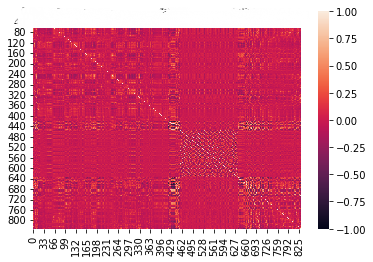

In [ ]:
for i in tqdm(range(100)):
  ax = sns.heatmap(corr_matrix, annot=True)

In [ ]:
---------- #fine prova 1

AttributeError: ignored

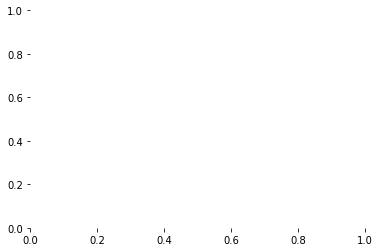

In [ ]:
sns.heatmap(full_matrix)
plt.show()